# GNN-Correlation Hyperparameter Search

Grid search over architecture and training hyperparameters for GNN-Correlation.
Fixed at θ=0.3 (ablation winner from 04_gnn_models.ipynb).

Grid: lr × hidden_dim × dropout × batch_norm × num_layers = 48 configs.

Resumable: if a run's checkpoint exists it is skipped, so you can restart after a Colab timeout.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import json
import itertools
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import config
from src.models import GNNModelV2
from src.train import set_seeds, run_gnn_hparam_search
from src.graphs import load_corr_graphs

In [2]:
# Load features, target, splits — same pattern as 04_gnn_models.ipynb
target = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'target.parquet')
splits = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'splits.parquet')
tickers = target.columns.tolist()

meta          = json.load(open(Path(config.DATA_FEATURES_DIR) / 'features_meta.json'))
feature_names = meta['feature_names']
feat_df       = pd.read_parquet(Path(config.DATA_FEATURES_DIR) / 'features.parquet')
feat_df['week'] = pd.to_datetime(feat_df['week'])
feat_df = feat_df[feat_df['week'].isin(target.index)].copy()
ticker_order    = {t: i for i, t in enumerate(tickers)}
feat_df['_ord'] = feat_df['ticker'].map(ticker_order)
feat_df = feat_df.sort_values(['week', '_ord']).drop(columns='_ord')

n_weeks  = target.shape[0]
n_stocks = target.shape[1]
n_feats  = len(feature_names)

features_3d = feat_df[feature_names].values.reshape(n_weeks, n_stocks, n_feats)
target_arr  = target.values

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

assert features_3d.shape == (n_weeks, n_stocks, n_feats)
assert target_arr.shape  == (n_weeks, n_stocks)
print(f'features_3d: {features_3d.shape}  target_arr: {target_arr.shape}')
print(f'tickers: {len(tickers)}  n_feats: {n_feats}  device: {device}')

features_3d: (572, 465, 10)  target_arr: (572, 465)
tickers: 465  n_feats: 10  device: cuda


In [3]:
# Load precomputed correlation graphs at θ=0.3 for train and val weeks.
# precompute_corr_graphs() was already run in 04_gnn_models.ipynb so this is a fast dict load.
theta = config.CORR_THRESHOLD  # 0.3
corr_graphs_03 = {
    **load_corr_graphs(theta, 'train'),
    **load_corr_graphs(theta, 'val'),
}
print(f'Loaded {len(corr_graphs_03)} weeks of correlation graphs at θ={theta}')

Loaded 469 weeks of correlation graphs at θ=0.3


In [4]:
# Show the full grid before starting.
grid = [
    {
        'lr': lr,
        'hidden_dim': hd,
        'dropout': do,
        'batch_norm': bn,
        'num_layers': nl,
    }
    for lr in config.GNN_HPARAM_LR
    for hd in config.GNN_HPARAM_HIDDEN
    for do in config.GNN_HPARAM_DROPOUT
    for bn in config.GNN_HPARAM_BATCH_NORM
    for nl in config.GNN_HPARAM_NUM_LAYERS
]

grid_df = pd.DataFrame(grid)
grid_df.index.name = 'config_idx'

print(f'Total configs: {len(grid)}')
print(f'\nGrid axes:')
print(f'  lr         : {config.GNN_HPARAM_LR}')
print(f'  hidden_dim : {config.GNN_HPARAM_HIDDEN}')
print(f'  dropout    : {config.GNN_HPARAM_DROPOUT}')
print(f'  batch_norm : {config.GNN_HPARAM_BATCH_NORM}')
print(f'  num_layers : {config.GNN_HPARAM_NUM_LAYERS}')
print(f'  patience   : {config.GNN_HPARAM_PATIENCE} epochs (reduced from {config.EARLY_STOP_PATIENCE})')
print()

# Baseline to beat
baseline_mse = 0.019778
print(f'Baseline to beat: GNN-Correlation default config  val MSE={baseline_mse:.6f}')
print(f'  (lr=0.001, hidden=64, dropout=0.3, batch_norm=False, num_layers=2)')

Total configs: 48

Grid axes:
  lr         : [0.0003, 0.001, 0.003]
  hidden_dim : [64, 128]
  dropout    : [0.1, 0.3]
  batch_norm : [True, False]
  num_layers : [2, 3]
  patience   : 7 epochs (reduced from 10)

Baseline to beat: GNN-Correlation default config  val MSE=0.019778
  (lr=0.001, hidden=64, dropout=0.3, batch_norm=False, num_layers=2)


In [5]:
results_df, best_config = run_gnn_hparam_search(
    features=features_3d,
    target=target_arr,
    week_index=target.index,
    corr_graphs=corr_graphs_03,
    splits=splits,
    device=device,
    grid=grid,
    max_epochs=config.GNN_MAX_EPOCHS,
)


Config 1/48  [hparam_000]
  lr=0.0003  hidden=64  dropout=0.1  batch_norm=True  num_layers=2
  Parameters: 9,921


c:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\.venv\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:344: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(


Epoch   1  train=0.065507  val=0.024752
Epoch   2  train=0.049741  val=0.024542
Epoch   3  train=0.045555  val=0.024203
Epoch   4  train=0.043278  val=0.024488
Epoch   5  train=0.041962  val=0.024441
Epoch   6  train=0.040901  val=0.024517
Epoch   7  train=0.040338  val=0.024304
Epoch   8  train=0.039900  val=0.024736
Epoch   9  train=0.039419  val=0.024552
Epoch  10  train=0.039158  val=0.022908
Epoch  11  train=0.038894  val=0.022962
Epoch  12  train=0.038781  val=0.023056
Epoch  13  train=0.038627  val=0.022959
Epoch  14  train=0.038618  val=0.022823
Epoch  15  train=0.038454  val=0.022851
Epoch  16  train=0.038356  val=0.022896
Epoch  17  train=0.038398  val=0.022806
Epoch  18  train=0.038252  val=0.022861
Epoch  19  train=0.038195  val=0.022790
Epoch  20  train=0.038102  val=0.022858
Epoch  21  train=0.038080  val=0.022768
Epoch  22  train=0.037962  val=0.022691
Epoch  23  train=0.037937  val=0.022696
Epoch  24  train=0.037919  val=0.022715
Epoch  25  train=0.037854  val=0.022729


TypeError: Object of type int64 is not JSON serializable

In [7]:
import json, shutil
import pandas as pd
from pathlib import Path
import config

results_dir = Path(config.DATA_RESULTS_DIR)
ckpt_dir    = Path(config.CHECKPOINTS_DIR)

# Rebuild the same grid (identical order to the search)
grid = [
    {"lr": lr, "hidden_dim": hd, "dropout": do, "batch_norm": bn, "num_layers": nl}
    for lr in config.GNN_HPARAM_LR
    for hd in config.GNN_HPARAM_HIDDEN
    for do in config.GNN_HPARAM_DROPOUT
    for bn in config.GNN_HPARAM_BATCH_NORM
    for nl in config.GNN_HPARAM_NUM_LAYERS
]

run_records = []
missing = []
for i, cfg in enumerate(grid):
    loss_path = results_dir / f"gnn_hparam_{i:03d}_val_loss.json"
    ckpt_path = ckpt_dir    / f"gnn_hparam_{i:03d}_best.pt"
    if loss_path.exists():
        with open(loss_path) as fh:
            val_mse = json.load(fh)["best_val_loss"]
        run_records.append({**cfg, "config_idx": i, "val_mse": val_mse,
                            "checkpoint": str(ckpt_path)})
    else:
        missing.append(i)

print(f"Recovered {len(run_records)}/48 configs.  Missing: {missing}")

results_df = pd.DataFrame(run_records).sort_values("val_mse").reset_index(drop=True)
best_row   = results_df.iloc[0]
_type      = {"lr": float, "hidden_dim": int, "dropout": float, "batch_norm": bool, "num_layers": int}
best_config = {k: _type[k](best_row[k]) for k in _type}

best_src = ckpt_dir / f"gnn_hparam_{int(best_row['config_idx']):03d}_best.pt"
best_dst = ckpt_dir / "gnn_corr_hparam_best.pt"
shutil.copy2(best_src, best_dst)

results_path = results_dir / "gnn_hparam_search_results.json"
with open(results_path, "w") as fh:
    json.dump({"runs": run_records, "best_config": best_config,
                "best_val_mse": float(best_row["val_mse"]), "baseline_val_mse": None}, fh, indent=2)

print(f"\nBest val MSE : {best_row['val_mse']:.6f}")
print(f"Best config  : {best_config}")
print(f"Checkpoint   : {best_dst}")
print(f"\nTop 5:")
print(results_df[["lr","hidden_dim","dropout","batch_norm","num_layers","val_mse"]].head(5).to_string(index=True))

Recovered 48/48 configs.  Missing: []

Best val MSE : 0.019589
Best config  : {'lr': 0.0003, 'hidden_dim': 128, 'dropout': 0.3, 'batch_norm': False, 'num_layers': 3}
Checkpoint   : C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\checkpoints\gnn_corr_hparam_best.pt

Top 5:
       lr  hidden_dim  dropout  batch_norm  num_layers   val_mse
0  0.0003         128      0.3       False           3  0.019589
1  0.0010         128      0.3       False           3  0.019679
2  0.0030         128      0.1       False           3  0.019681
3  0.0010          64      0.1       False           3  0.019684
4  0.0010          64      0.3       False           3  0.019710


In [8]:
# Reload results from JSON in case this cell is run after a kernel restart.
results_path = Path(config.DATA_RESULTS_DIR) / 'gnn_hparam_search_results.json'
with open(results_path) as fh:
    saved = json.load(fh)

results_df = (
    pd.DataFrame(saved['runs'])
    .sort_values('val_mse')
    .reset_index(drop=True)
)
best_config = saved['best_config']

baseline_mse = 0.019778
results_df['vs_baseline'] = (results_df['val_mse'] - baseline_mse) / baseline_mse * 100

display_cols = ['lr', 'hidden_dim', 'dropout', 'batch_norm', 'num_layers', 'val_mse', 'vs_baseline']

print(f'Top 10 configs (sorted by val MSE):')
print(results_df[display_cols].head(10).to_string(index=True, float_format=lambda x: f'{x:.6f}'))
print()
print(f'Baseline (default config) val MSE : {baseline_mse:.6f}')
print(f'Best found val MSE                : {results_df["val_mse"].iloc[0]:.6f}')
delta = (results_df['val_mse'].iloc[0] - baseline_mse) / baseline_mse * 100
print(f'Change vs baseline                : {delta:+.2f}%')
print()
print(f'Best config: {best_config}')

Top 10 configs (sorted by val MSE):
        lr  hidden_dim  dropout  batch_norm  num_layers  val_mse  vs_baseline
0 0.000300         128 0.300000       False           3 0.019589    -0.953968
1 0.001000         128 0.300000       False           3 0.019679    -0.500540
2 0.003000         128 0.100000       False           3 0.019681    -0.491580
3 0.001000          64 0.100000       False           3 0.019684    -0.473333
4 0.001000          64 0.300000       False           3 0.019710    -0.343752
5 0.001000         128 0.300000       False           2 0.019736    -0.212274
6 0.001000          64 0.300000       False           2 0.019791     0.065436
7 0.003000          64 0.100000       False           3 0.019840     0.311073
8 0.001000         128 0.100000       False           2 0.019842     0.321663
9 0.003000         128 0.300000       False           2 0.019852     0.375518

Baseline (default config) val MSE : 0.019778
Best found val MSE                : 0.019589
Change vs basel

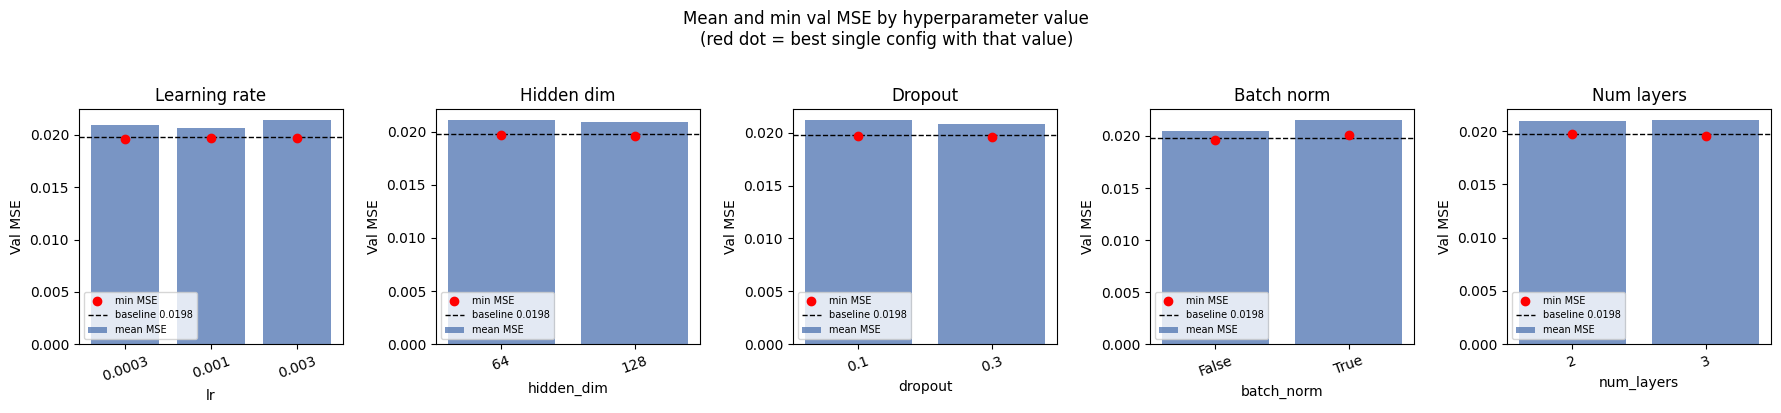

Saved: figures/gnn_hparam_search.png


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

params = [
    ('lr',          'Learning rate'),
    ('hidden_dim',  'Hidden dim'),
    ('dropout',     'Dropout'),
    ('batch_norm',  'Batch norm'),
    ('num_layers',  'Num layers'),
]

for ax, (col, label) in zip(axes, params):
    group_mean = results_df.groupby(col)['val_mse'].mean()
    group_min  = results_df.groupby(col)['val_mse'].min()
    x_vals = [str(v) for v in group_mean.index]
    ax.bar(x_vals, group_mean.values, color='#4C72B0', alpha=0.75, label='mean MSE')
    ax.scatter(x_vals, group_min.values, color='red', zorder=5, label='min MSE')
    ax.axhline(baseline_mse, color='black', linestyle='--', linewidth=1,
               label=f'baseline {baseline_mse:.4f}')
    ax.set_title(label)
    ax.set_xlabel(col)
    ax.set_ylabel('Val MSE')
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Mean and min val MSE by hyperparameter value\n(red dot = best single config with that value)', y=1.02)
plt.tight_layout()
plt.savefig(Path(config.FIGURES_DIR) / 'gnn_hparam_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/gnn_hparam_search.png')

In [10]:
# Load the best checkpoint and verify it produces valid predictions on a sample week.
best_ckpt = Path(config.CHECKPOINTS_DIR) / 'gnn_corr_hparam_best.pt'
assert best_ckpt.exists(), f'Best checkpoint not found: {best_ckpt}'

set_seeds()
best_model = GNNModelV2(
    in_channels=n_feats,
    hidden_dim=best_config['hidden_dim'],
    dropout=best_config['dropout'],
    num_layers=best_config['num_layers'],
    batch_norm=best_config['batch_norm'],
).to(device)
best_model.load_state_dict(torch.load(best_ckpt, map_location=device, weights_only=True))
best_model.eval()

# Pick a validation week for a quick sanity check
val_weeks = splits.loc[splits['split'] == 'val', 'week'].sort_values()
sample_week = val_weeks.iloc[25]  # mid-val
sample_pos  = list(target.index).index(sample_week)

sample_ei = corr_graphs_03.get(sample_week, torch.zeros(2, 0, dtype=torch.long)).to(device)
x_sample  = torch.tensor(features_3d[sample_pos], dtype=torch.float32).to(device)

with torch.no_grad():
    pred = best_model(x_sample, sample_ei)

print(f'Best model architecture:')
print(best_model)
print(f'\nParameters: {sum(p.numel() for p in best_model.parameters()):,}')
print(f'\nSanity check at {sample_week.date()}:')
print(f'  Output shape : {tuple(pred.shape)}')
print(f'  NaNs         : {pred.isnan().sum().item()}')
print(f'  min / max    : {pred.min().item():.4f} / {pred.max().item():.4f}')
print(f'\nCheckpoint    : {best_ckpt}')

Best model architecture:
GNNModelV2(
  (convs): ModuleList(
    (0): SAGEConv(10, 128, aggr=mean)
    (1-2): 2 x SAGEConv(128, 128, aggr=mean)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Parameters: 68,609

Sanity check at 2023-06-26:
  Output shape : (465,)
  NaNs         : 0
  min / max    : 0.1379 / 0.5408

Checkpoint    : C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\data\results\checkpoints\gnn_corr_hparam_best.pt


C:\Users\Rylan Wade\Desktop\FinancialAnalytics\Final_Project\src\models.py:344: UserWarning: GNNModelV2.forward: input features contain NaN values. Imputing with 0 (z-score mean). Expected during warm-up weeks.
  warnings.warn(
